In [2]:
# ----------------------------
# Cell 1 — Imports and paths
# ----------------------------
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import celltypist
from celltypist import models
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase2_clustering_v2"
RESULTS_DIR = PROJECT_DIR / "results" / "phase2_clustering_v2"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Paths set up")

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


Paths set up


In [3]:
# ----------------------------
# Cell 2 — Load v2 processed objects
# ----------------------------
adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase1_v2.h5ad")
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase1_v2.h5ad")

print(adata1)
print(adata2)
print("\nGSE114725 raw:", adata1.raw)
print("GSE176078 raw:", adata2.raw)
print("\nGSE114725 obsm keys:", adata1.obsm.keys())
print("GSE176078 obsm keys:", adata2.obsm.keys())

AnnData object with n_obs × n_vars = 44662 × 2000
    obs: 'patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'patient_colors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 91425 × 2000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'orig.ident_colors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
# Cell 2 — Load annotated objects
adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad")
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase2_v2_annotated.h5ad")

print(adata1)
print(adata2)

AnnData object with n_obs × n_vars = 44662 × 2000
    obs: 'patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'celltypist', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'celltypist_colors', 'hvg', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_1.0', 'leiden_1.0_colors', 'log1p', 'neighbors', 'patient_colors', 'pca', 'rank_genes_leiden_0.8', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 91425 × 2000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 

In [3]:
# ----------------------------
# Cell 3 — Leiden clustering
# ----------------------------
def run_phase2_clustering(adata, dataset_name, n_pcs=30):
    print(f"Running Phase 2 clustering for {dataset_name}")

    sc.pp.neighbors(
        adata,
        use_rep="X_pca_harmony",
        n_neighbors=15,
        n_pcs=n_pcs
    )

    sc.tl.umap(adata, random_state=42)

    for resolution in [0.2, 0.4, 0.6, 0.8, 1.0]:
        key = f"leiden_{resolution}"
        sc.tl.leiden(
            adata,
            resolution=resolution,
            key_added=key,
            flavor="igraph",
            n_iterations=2,
            directed=False
        )
        print(f"  {dataset_name} {key}: {adata.obs[key].nunique()} clusters")

    return adata

adata1 = run_phase2_clustering(adata1, "GSE114725")
adata2 = run_phase2_clustering(adata2, "GSE176078")

print("\nGSE114725 obs columns:", adata1.obs.columns.tolist())
print("GSE176078 obs columns:", adata2.obs.columns.tolist())

Running Phase 2 clustering for GSE114725


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  GSE114725 leiden_0.2: 2 clusters
  GSE114725 leiden_0.4: 2 clusters
  GSE114725 leiden_0.6: 6 clusters
  GSE114725 leiden_0.8: 6 clusters
  GSE114725 leiden_1.0: 9 clusters
Running Phase 2 clustering for GSE176078
  GSE176078 leiden_0.2: 16 clusters
  GSE176078 leiden_0.4: 22 clusters
  GSE176078 leiden_0.6: 26 clusters
  GSE176078 leiden_0.8: 31 clusters
  GSE176078 leiden_1.0: 33 clusters

GSE114725 obs columns: ['patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0']
GSE176078 obs columns: ['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0']


In [4]:
# ----------------------------
# Cell 4 — Resolution comparison UMAPs
# ----------------------------
fig, axes = plt.subplots(1, 5, figsize=(30, 5))
for i, res in enumerate(["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"]):
    sc.pl.umap(adata1, color=res, title=f"GSE114725 {res}",
               legend_loc="on data", legend_fontsize=8, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_resolution_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
for i, res in enumerate(["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"]):
    sc.pl.umap(adata2, color=res, title=f"GSE176078 {res}",
               legend_loc="on data", legend_fontsize=8, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_resolution_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved — open figures to inspect")

Saved — open figures to inspect


In [5]:
# Quick check — colour UMAP by tissue and patient for GSE114725
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata1, color="tissue", title="GSE114725 tissue", ax=axes[0], show=False)
sc.pl.umap(adata1, color="patient", title="GSE114725 patient", ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_tissue_patient_umap.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved")

Saved


In [6]:
# ----------------------------
# Cell 5 — Save clustered objects
# ----------------------------
adata1.write(
    PROCESSED_DIR / "GSE114725_phase2_v2_clustered.h5ad",
    compression="gzip"
)
adata2.write(
    PROCESSED_DIR / "GSE176078_phase2_v2_clustered.h5ad",
    compression="gzip"
)
print("Saved")

Saved


In [7]:
# ----------------------------
# Cell 6 — Marker gene identification
# ----------------------------
vdj_prefixes = (
    "IGHV", "IGLV", "IGKV", "TRAV", "TRBV", "TRGV", "TRDV",
    "IGHD", "IGHJ", "IGLJ", "IGKJ",
    "TRAC", "TRBC", "TRGC", "TRDC",
    "IGHA", "IGHE", "IGHG", "IGHM", "IGLC", "IGKC"
)

# GSE114725 — resolution 0.8
sc.tl.rank_genes_groups(
    adata1,
    groupby="leiden_0.8",
    method="wilcoxon",
    key_added="rank_genes_leiden_0.8"
)

markers1 = sc.get.rank_genes_groups_df(
    adata1,
    group=None,
    key="rank_genes_leiden_0.8"
)

clean_markers1 = markers1[
    ~markers1["names"].str.startswith(vdj_prefixes)
]

top10_clean1 = (
    clean_markers1
    .groupby("group")
    .head(10)
    .reset_index(drop=True)
)

print("GSE114725 top markers per cluster:")
for cluster in sorted(top10_clean1["group"].unique(), key=lambda x: int(x)):
    genes = top10_clean1[top10_clean1["group"] == cluster]["names"].tolist()
    print(f"\n{'='*40}\nCluster {cluster}\n{'='*40}")
    for gene in genes:
        print(gene)

top10_clean1.to_csv(RESULTS_DIR / "GSE114725_markers_v2.csv", index=False)

# GSE176078 — resolution 0.6
sc.tl.rank_genes_groups(
    adata2,
    groupby="leiden_0.6",
    method="wilcoxon",
    key_added="rank_genes_leiden_0.6"
)

markers2 = sc.get.rank_genes_groups_df(
    adata2,
    group=None,
    key="rank_genes_leiden_0.6"
)

clean_markers2 = markers2[
    ~markers2["names"].str.startswith(vdj_prefixes)
]

top10_clean2 = (
    clean_markers2
    .groupby("group")
    .head(10)
    .reset_index(drop=True)
)

print("\nGSE176078 top markers per cluster:")
for cluster in sorted(top10_clean2["group"].unique(), key=lambda x: int(x)):
    genes = top10_clean2[top10_clean2["group"] == cluster]["names"].tolist()
    print(f"\n{'='*40}\nCluster {cluster}\n{'='*40}")
    for gene in genes:
        print(gene)

top10_clean2.to_csv(RESULTS_DIR / "GSE176078_markers_v2.csv", index=False)
print("\nSaved marker tables")

GSE114725 top markers per cluster:

Cluster 0
RPLP2
RPS29
RPL13
RPS27
RPL13A
RPS12
TPT1
RPL10
RPL30
RPS27A

Cluster 1
RPS27
RPLP2
RPL13A
RPL13
RPL30
RPS29
RPS8
RPS12
RPS18
RPS11

Cluster 2
NKG7
B2M
GNLY
CCL5
PRF1
HLA-B
CST7
KLRD1
FGFBP2
GZMA

Cluster 3
CD69
DUSP1
TSC22D3
FOS
JUN
JUNB
ZFP36
FOSB
CXCR4
RGS1

Cluster 4
CD74
HLA-DRA
FTH1
FTL
HLA-DPA1
HLA-DPB1
HLA-DRB1
CST3
PSAP
LYZ

Cluster 5
CST3
FTL
PSAP
HLA-DRA
FTH1
TYROBP
CD74
HLA-DRB1
GRN
CEBPD


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:463: PerformanceWarning: DataFrame is high


GSE176078 top markers per cluster:

Cluster 0
PLVAP
RAMP2
VWF
SPARCL1
IGFBP7
ENG
GNG11
PECAM1
AQP1
HSPG2

Cluster 1
SRP14
RAMP2
CAV1
A2M
CLDN5
TM4SF1
IFI27
IFITM3
GNG11
CLEC14A

Cluster 2
COL1A2
DCN
COL1A1
CTSK
C1S
COL6A2
LUM
COL6A1
COL3A1
COL6A3

Cluster 3
MYL9
IGFBP7
CALD1
TPM2
TAGLN
ACTA2
SPARCL1
SOD3
CAV1
NDUFA4L2

Cluster 4
KRT14
KRT17
KRT5
TAGLN
MT1X
CSRP1
DST
MYLK
ACTA2
C2orf40

Cluster 5
MS4A1
HLA-DRA
CD37
CD74
CD79A
HLA-DPB1
HLA-DPA1
HLA-DQB1
HLA-DQA1
RPS23

Cluster 6
STMN1
HMGB2
TUBB
HMGN2
TUBA1B
HMGB1
H2AFZ
PFN1
MKI67
GAPDH

Cluster 7
MZB1
SSR4
SEC11C
DERL3
FKBP11
HSP90B1
HERPUD1
XBP1
ITM2C
CD79A

Cluster 8
STMN1
UBE2C
BIRC5
CKS1B
HMGB1
TUBB
TK1
CENPF
CD24
H2AFZ

Cluster 9
CCL5
NKG7
CCL4
CD8A
CD3E
CST7
CD69
B2M
CD52
HCST

Cluster 10
NKG7
GNLY
KLRD1
CTSW
CCL5
CD7
CST7
SRGN
GZMB
HOPX

Cluster 11
B2M
IL32
CD2
CD3D
PTPRC
SRGN
CD3E
RGS1
TIGIT
BTG1

Cluster 12
IL7R
RPS27
RPL30
RPS25
BTG1
RPS12
RPS3
RPS15A
RPL32
CXCR4

Cluster 13
TACSTD2
KRT7
SLPI
KRT15
MGST1
PERP
CLDN4
RARRES1
SF

In [8]:
# ----------------------------
# Cell 7 — CellTypist annotation
# ----------------------------

# GSE114725 — use adata.raw.to_adata() to get full gene normalised object
adata1_raw = adata1.raw.to_adata()
adata1_raw.obsm["X_umap"] = adata1.obsm["X_umap"]
adata1_raw.obs["leiden_0.8"] = adata1.obs["leiden_0.8"]

predictions1 = celltypist.annotate(
    adata1_raw,
    model="Immune_All_High.pkl",
    majority_voting=True
)
adata1_raw = predictions1.to_adata()

print("GSE114725 CellTypist results:")
print(adata1_raw.obs["majority_voting"].value_counts())

🔬 Input data has 44662 cells and 14800 genes
🔗 Matching reference genes in the model
🧬 4838 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!


GSE114725 CellTypist results:
majority_voting
T cells        36054
Macrophages     3107
ILC             1831
B cells         1797
Monocytes       1248
Mast cells       287
DC               257
pDC               81
Name: count, dtype: int64


In [9]:
# ----------------------------
# GSE176078 — batched CellTypist
# ----------------------------
adata2_raw = adata2.raw.to_adata()
adata2_raw.obsm["X_umap"] = adata2.obsm["X_umap"]
adata2_raw.obs["leiden_0.6"] = adata2.obs["leiden_0.6"]

def run_celltypist_batched(adata_full, model_name, batch_size=20000):
    n_cells = adata_full.n_obs
    all_predictions = []
    
    for start in range(0, n_cells, batch_size):
        end = min(start + batch_size, n_cells)
        print(f"Processing cells {start} to {end}...")
        
        batch = adata_full[start:end].copy()
        
        pred = celltypist.annotate(
            batch,
            model=model_name,
            majority_voting=False
        )
        all_predictions.append(pred.predicted_labels)
    
    combined = pd.concat(all_predictions)
    adata_full.obs["predicted_labels"] = combined["predicted_labels"].values
    
    print("Batched prediction done!")
    return adata_full

adata2_raw = run_celltypist_batched(
    adata2_raw,
    "Immune_All_High.pkl",
    batch_size=20000
)

print("\nGSE176078 CellTypist results:")
print(adata2_raw.obs["predicted_labels"].value_counts())

Processing cells 0 to 20000...


🔬 Input data has 20000 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Processing cells 20000 to 40000...


🔬 Input data has 20000 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data


MemoryError: Unable to allocate 815. MiB for an array with shape (20000, 5340) and data type float64

In [10]:
adata2_raw = run_celltypist_batched(
    adata2_raw,
    "Immune_All_High.pkl",
    batch_size=10000
)

print("\nGSE176078 CellTypist results:")
print(adata2_raw.obs["predicted_labels"].value_counts())

Processing cells 0 to 10000...


🔬 Input data has 10000 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Processing cells 10000 to 20000...


🔬 Input data has 10000 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Processing cells 20000 to 30000...


...

Processing cells 80000 to 90000...


🔬 Input data has 10000 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Processing cells 90000 to 91425...


🔬 Input data has 1425 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Batched prediction done!

GSE176078 CellTypist results:
predicted_labels
T cells                       29490
Epithelial cells              23837
Macrophages                    8758
Endothelial cells              8112
Fibroblasts                    7592
ILC                            3859
B cells                        3436
Plasma cells                   2595
DC                             1645
Monocytes                      1118
Double-positive thymocytes      546
pDC                             319
Cycling cells                    26
HSC/MPP                          19
Mono-mac                         18
Mast cells                       14
Double-negative thymocytes       13
Myelocytes                       12
MNP                               9
ETP                               3
Erythroid                         2
B-cell lineage                    1
Megakaryocytes/platelets          1
Name: count, dtype: int64


In [11]:
# ----------------------------
# Cell 8 — Transfer labels and plot UMAPs
# ----------------------------

# Transfer CellTypist labels to main clustered objects
adata1.obs["celltypist"] = adata1_raw.obs["majority_voting"].values
adata2.obs["celltypist"] = adata2_raw.obs["predicted_labels"].values

# Plot
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

sc.pl.umap(
    adata1,
    color="celltypist",
    title="GSE114725 — CellTypist",
    legend_loc="on data",
    legend_fontsize=7,
    ax=axes[0],
    show=False
)

sc.pl.umap(
    adata2,
    color="celltypist",
    title="GSE176078 — CellTypist",
    legend_loc="on data",
    legend_fontsize=7,
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "celltypist_umap_both_v2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("Saved")

# Compare GSE176078 CellTypist vs published labels
crosstab = pd.crosstab(
    adata2.obs["celltype_major"],
    adata2.obs["celltypist"]
)
crosstab.to_csv(RESULTS_DIR / "GSE176078_celltypist_vs_published_v2.csv")
print(crosstab)

... storing 'celltypist' as categorical


Saved
celltypist         B cells  B-cell lineage  Cycling cells    DC  \
celltype_major                                                    
B-cells               2707               0              0     5   
CAFs                    41               0              1    15   
Cancer Epithelial      331               0              4    97   
Endothelial             10               0              0     0   
Myeloid                 23               0              0  1306   
Normal Epithelial       21               0              0     2   
PVL                    270               1              0   211   
Plasmablasts             5               0              0     1   
T-cells                 28               0             21     8   

celltypist         Double-negative thymocytes  Double-positive thymocytes  \
celltype_major                                                              
B-cells                                     0                           0   
CAFs                     

In [12]:
# ----------------------------
# Cell 9 — Save annotated objects
# ----------------------------
adata1.write(
    PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad",
    compression="gzip"
)
print("GSE114725 saved")

adata2.write(
    PROCESSED_DIR / "GSE176078_phase2_v2_annotated.h5ad",
    compression="gzip"
)
print("GSE176078 saved")

GSE114725 saved
GSE176078 saved


In [14]:
# ----------------------------
# Cell 10 — Assign cell type labels
# ----------------------------

# GSE114725 — resolution 0.8 (6 clusters)
cluster_labels_1 = {
    "0": "T cells (resting)",
    "1": "T cells (naive/memory)",
    "2": "NK/Cytotoxic T cells",
    "3": "Activated T cells",
    "4": "Macrophages",
    "5": "Monocytes/DC"
}

# GSE176078 — resolution 0.6 (26 clusters)
cluster_labels_2 = {
    "0": "Endothelial cells",
    "1": "Endothelial cells",
    "2": "CAFs",
    "3": "PVL",
    "4": "Basal epithelial",
    "5": "B cells",
    "6": "Cycling cells",
    "7": "Plasma cells",
    "8": "Cycling epithelial",
    "9": "CD8 T cells",
    "10": "NK cells",
    "11": "T cells",
    "12": "Naive/memory T cells",
    "13": "Luminal epithelial",
    "14": "Macrophages",
    "15": "Monocytes/DC",
    "16": "Cycling myeloid",
    "17": "pDC",
    "18": "Luminal epithelial",
    "19": "Luminal epithelial",
    "20": "Epithelial",
    "21": "Epithelial",
    "22": "Luminal epithelial",
    "23": "Luminal epithelial",
    "24": "Luminal epithelial",
    "25": "Luminal epithelial"
}

# Apply labels
adata1.obs["cell_type"] = adata1.obs["leiden_0.8"].map(cluster_labels_1)
adata2.obs["cell_type"] = adata2.obs["leiden_0.6"].map(cluster_labels_2)

print("GSE114725 cell type counts:")
print(adata1.obs["cell_type"].value_counts())
print("\nGSE176078 cell type counts:")
print(adata2.obs["cell_type"].value_counts())

GSE114725 cell type counts:
cell_type
T cells (resting)         11734
Macrophages                8691
NK/Cytotoxic T cells       8676
Activated T cells          7141
T cells (naive/memory)     4341
Monocytes/DC               4079
Name: count, dtype: int64

GSE176078 cell type counts:
cell_type
Luminal epithelial      22894
Naive/memory T cells    11590
CD8 T cells              9387
Macrophages              8705
Endothelial cells        7040
CAFs                     6453
T cells                  5989
PVL                      5051
Cycling epithelial       3010
B cells                  2791
Plasma cells             2583
NK cells                 2438
Cycling cells            1159
Basal epithelial         1074
Epithelial                905
pDC                       315
Monocytes/DC               22
Cycling myeloid            19
Name: count, dtype: int64


In [15]:
# ----------------------------
# Cell 11 — Publication-quality annotated UMAPs
# ----------------------------
import matplotlib.pyplot as plt

# GSE114725
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(
    adata1,
    color="cell_type",
    title="GSE114725 — Breast Cancer Immune TME\nCell Type Annotation",
    legend_loc="right margin",
    legend_fontsize=10,
    frameon=True,
    ax=ax,
    show=False
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "GSE114725_annotated_umap_v2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("GSE114725 annotated UMAP saved")

# GSE176078
fig, ax = plt.subplots(figsize=(14, 10))
sc.pl.umap(
    adata2,
    color="cell_type",
    title="GSE176078 — Breast Cancer TME\nCell Type Annotation",
    legend_loc="right margin",
    legend_fontsize=10,
    frameon=True,
    ax=ax,
    show=False
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "GSE176078_annotated_umap_v2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("GSE176078 annotated UMAP saved")

# Save annotation tables
annotation_table1 = pd.DataFrame({
    "cluster": list(cluster_labels_1.keys()),
    "cell_type": list(cluster_labels_1.values())
})
annotation_table1["n_cells"] = annotation_table1["cluster"].map(
    adata1.obs["leiden_0.8"].value_counts()
)
annotation_table1.to_csv(
    RESULTS_DIR / "GSE114725_cluster_annotations_v2.csv",
    index=False
)

annotation_table2 = pd.DataFrame({
    "cluster": list(cluster_labels_2.keys()),
    "cell_type": list(cluster_labels_2.values())
})
annotation_table2["n_cells"] = annotation_table2["cluster"].map(
    adata2.obs["leiden_0.6"].value_counts()
)
annotation_table2.to_csv(
    RESULTS_DIR / "GSE176078_cluster_annotations_v2.csv",
    index=False
)

print("Annotation tables saved")

GSE114725 annotated UMAP saved


... storing 'cell_type' as categorical


GSE176078 annotated UMAP saved
Annotation tables saved


In [16]:
# ----------------------------
# Cell 12 — Save final annotated objects
# ----------------------------
adata1.write(
    PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad",
    compression="gzip"
)
print("GSE114725 saved")

adata2.write(
    PROCESSED_DIR / "GSE176078_phase2_v2_annotated.h5ad",
    compression="gzip"
)
print("GSE176078 saved")

GSE114725 saved
GSE176078 saved


In [17]:
# ----------------------------
# Stretch 3 — Cell type proportions
# ----------------------------

# GSE114725 — proportions per patient
prop1 = (
    adata1.obs
    .groupby(["patient", "cell_type"])
    .size()
    .reset_index(name="n_cells")
)

# Calculate percentage per patient
prop1["total"] = prop1.groupby("patient")["n_cells"].transform("sum")
prop1["proportion"] = prop1["n_cells"] / prop1["total"] * 100

print("GSE114725 cell type proportions per patient:")
print(prop1.pivot(index="patient", columns="cell_type", values="proportion").round(2))

# GSE176078 — proportions per breast cancer subtype
prop2 = (
    adata2.obs
    .groupby(["subtype", "cell_type"])
    .size()
    .reset_index(name="n_cells")
)

prop2["total"] = prop2.groupby("subtype")["n_cells"].transform("sum")
prop2["proportion"] = prop2["n_cells"] / prop2["total"] * 100

print("\nGSE176078 cell type proportions per subtype:")
print(prop2.pivot(index="subtype", columns="cell_type", values="proportion").round(2))

# Save
prop1.to_csv(RESULTS_DIR / "GSE114725_celltype_proportions.csv", index=False)
prop2.to_csv(RESULTS_DIR / "GSE176078_celltype_proportions_by_subtype.csv", index=False)
print("\nSaved proportion tables")

GSE114725 cell type proportions per patient:
cell_type  T cells (resting)  T cells (naive/memory)  NK/Cytotoxic T cells  \
patient                                                                      
BC1                    29.51                   11.51                 22.02   
BC2                    29.60                   11.66                 20.56   
BC3                    11.94                    3.24                  9.82   
BC4                    29.59                   10.92                 21.58   
BC5                    15.82                    4.48                 14.00   
BC6                    12.53                    4.58                 12.15   
BC7                    20.56                    6.87                 13.31   
BC8                    17.64                    4.85                 14.41   

cell_type  Activated T cells  Macrophages  Monocytes/DC  
patient                                                  
BC1                    14.74        15.51          6.70  


In [18]:
# ----------------------------
# Stretch 3 — Proportion plots
# ----------------------------
import matplotlib.pyplot as plt
import numpy as np

# GSE114725 stacked bar
pivot1 = prop1.pivot(
    index="patient",
    columns="cell_type",
    values="proportion"
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot1.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab10"
)
ax.set_title("GSE114725 — Cell Type Proportions per Patient", fontsize=14)
ax.set_xlabel("Patient")
ax.set_ylabel("Proportion (%)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "GSE114725_celltype_proportions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("GSE114725 proportion plot saved")

# GSE176078 stacked bar by subtype
pivot2 = prop2.pivot(
    index="subtype",
    columns="cell_type",
    values="proportion"
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
pivot2.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab20"
)
ax.set_title("GSE176078 — Cell Type Proportions per Breast Cancer Subtype", fontsize=14)
ax.set_xlabel("Subtype")
ax.set_ylabel("Proportion (%)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "GSE176078_celltype_proportions_subtype.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("GSE176078 proportion plot saved")

GSE114725 proportion plot saved
GSE176078 proportion plot saved


In [6]:
# ----------------------------
# Stretch 1 — T cell sub-clustering (GSE114725)
# ----------------------------

# Extract all T cell clusters including NK/Cytotoxic
t_cell_labels = [
    "T cells (resting)",
    "T cells (naive/memory)",
    "Activated T cells",
    "NK/Cytotoxic T cells"
]

adata1_tcells = adata1[
    adata1.obs["cell_type"].isin(t_cell_labels)
].copy()

print(f"T cells extracted: {adata1_tcells.n_obs} cells")
print(adata1_tcells.obs["cell_type"].value_counts())

# Re-run PCA and neighbours on T cell subset only
sc.pp.neighbors(
    adata1_tcells,
    use_rep="X_pca_harmony",
    n_neighbors=15,
    n_pcs=30
)

sc.tl.umap(adata1_tcells, random_state=42)

# Sub-cluster at multiple resolutions
for res in [0.3, 0.5, 0.7]:
    sc.tl.leiden(
        adata1_tcells,
        resolution=res,
        key_added=f"tcell_leiden_{res}",
        flavor="igraph",
        n_iterations=2,
        directed=False
    )
    print(f"Resolution {res}: {adata1_tcells.obs[f'tcell_leiden_{res}'].nunique()} clusters")

T cells extracted: 31892 cells
cell_type
T cells (resting)         11734
NK/Cytotoxic T cells       8676
Activated T cells          7141
T cells (naive/memory)     4341
Name: count, dtype: int64


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resolution 0.3: 2 clusters
Resolution 0.5: 4 clusters
Resolution 0.7: 5 clusters


In [7]:
# Run marker genes on T cell sub-clusters
sc.tl.rank_genes_groups(
    adata1_tcells,
    groupby="tcell_leiden_0.7",
    method="wilcoxon",
    key_added="rank_genes_tcell"
)

tcell_markers = sc.get.rank_genes_groups_df(
    adata1_tcells,
    group=None,
    key="rank_genes_tcell"
)

# Top 10 per cluster
top10_tcell = (
    tcell_markers
    .groupby("group")
    .head(10)
    .reset_index(drop=True)
)

for cluster in sorted(top10_tcell["group"].unique(), key=lambda x: int(x)):
    genes = top10_tcell[top10_tcell["group"] == cluster]["names"].tolist()
    print(f"\n{'='*40}\nT cell sub-cluster {cluster}\n{'='*40}")
    for gene in genes:
        print(gene)

# Plot UMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(
    adata1_tcells,
    color="tcell_leiden_0.7",
    title="T cell sub-clusters",
    legend_loc="on data",
    legend_fontsize=10,
    ax=axes[0],
    show=False
)

sc.pl.umap(
    adata1_tcells,
    color="cell_type",
    title="Original annotation",
    legend_loc="on data",
    legend_fontsize=8,
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "GSE114725_tcell_subclusters.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("Saved")


T cell sub-cluster 0
HLA-DRA
CD74
CD79A
CD37
HLA-DPB1
HLA-DQB1
RPS8
RPS11
HLA-DPA1
RPLP2

T cell sub-cluster 1
NKG7
GNLY
CCL5
PRF1
B2M
HLA-B
CST7
KLRD1
FGFBP2
PFN1

T cell sub-cluster 2
RPLP2
RPL13
RPS27
RPL30
RPL13A
RPS29
TPT1
RPS12
RPS8
RPL37

T cell sub-cluster 3
TPT1
RPLP2
RPL13
RPS12
RPL30
RPL13A
RPS29
RPL10
RPL19
RPS27A

T cell sub-cluster 4
SRGN
FOS
DUSP1
ZFP36
FOSB
JUN
RGS1
JUNB
TSC22D3
NFKBIA
Saved


In [8]:
# Assign T cell sub-cluster labels
tcell_labels = {
    "0": "B cell contamination",
    "1": "NK/Cytotoxic T cells",
    "2": "Resting T cells",
    "3": "Naive/Memory T cells",
    "4": "Activated T cells"
}

adata1_tcells.obs["tcell_subtype"] = adata1_tcells.obs["tcell_leiden_0.7"].map(tcell_labels)

# Publication quality UMAP
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(
    adata1_tcells,
    color="tcell_subtype",
    title="GSE114725 — T Cell Sub-clustering",
    legend_loc="right margin",
    legend_fontsize=10,
    frameon=True,
    ax=ax,
    show=False
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "GSE114725_tcell_annotated_umap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# Save marker table
top10_tcell.to_csv(
    RESULTS_DIR / "GSE114725_tcell_subcluster_markers.csv",
    index=False
)

print("T cell sub-cluster counts:")
print(adata1_tcells.obs["tcell_subtype"].value_counts())
print("Saved")

T cell sub-cluster counts:
tcell_subtype
Naive/Memory T cells    8835
NK/Cytotoxic T cells    6529
Activated T cells       6200
Resting T cells         5336
B cell contamination    4992
Name: count, dtype: int64
Saved


In [9]:
# ----------------------------
# Stretch 2 — Reference atlas comparison (GSE176078)
# ----------------------------

# Compare our annotations against published celltype_major labels
comparison = pd.crosstab(
    adata2.obs["cell_type"],
    adata2.obs["celltype_major"],
    normalize="index"
).round(3) * 100

print("Our annotation vs published labels (% of our cells in each published category):")
print(comparison)

# Also check celltype_minor for finer resolution
comparison_minor = pd.crosstab(
    adata2.obs["cell_type"],
    adata2.obs["celltype_major"]
)

comparison_minor.to_csv(
    RESULTS_DIR / "GSE176078_our_vs_published_comparison.csv"
)
print("\nSaved comparison table")

# Summary statistics
print("\nOverall concordance summary:")
for cell_type in comparison.index:
    top_match = comparison.loc[cell_type].idxmax()
    top_pct = comparison.loc[cell_type].max()
    print(f"  {cell_type} → {top_match}: {top_pct:.1f}%")

Our annotation vs published labels (% of our cells in each published category):
celltype_major        B-cells  CAFs  Cancer Epithelial  Endothelial  Myeloid  \
cell_type                                                                      
B cells                  96.9   0.0                0.3          0.8      1.0   
Basal epithelial          0.0   0.1                4.4          0.1      0.0   
CAFs                      0.0  89.3               10.3          0.0      0.0   
CD8 T cells               0.0   0.0                0.0          0.0      0.0   
Cycling cells             0.0   0.0                2.7          0.0      0.5   
Cycling epithelial        0.0   0.0               98.5          0.0      0.0   
Cycling myeloid           0.0   0.0              100.0          0.0      0.0   
Endothelial cells         0.0   0.0                0.0         99.5      0.1   
Epithelial                0.1   0.0               97.3          0.0      0.0   
Luminal epithelial        0.0   0.0     

In [10]:
# Save T cell sub-clustering results
adata1_tcells.write(
    PROCESSED_DIR / "GSE114725_tcells_subclustered.h5ad",
    compression="gzip"
)
print("T cell object saved")

T cell object saved


In [4]:
cluster_labels_1 = {
    "0": "T cells (resting)", "1": "T cells (naive/memory)",
    "2": "NK/Cytotoxic T cells", "3": "Activated T cells",
    "4": "Macrophages", "5": "Monocytes/DC"
}

In [5]:
# ----------------------------
# Macrophage sub-clustering (GSE114725)
# ----------------------------
import gc

# Load annotated object
adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad")
adata1.obs["cell_type"] = adata1.obs["leiden_0.8"].map(cluster_labels_1)

# Extract macrophages
adata1_mac = adata1[adata1.obs["cell_type"] == "Macrophages"].copy()
del adata1
gc.collect()

print(f"Macrophages extracted: {adata1_mac.n_obs} cells")
print(adata1_mac.obs["tissue"].value_counts())

# Re-run neighbours and UMAP on macrophage subset
sc.pp.neighbors(adata1_mac, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30)
sc.tl.umap(adata1_mac, random_state=42)

# Sub-cluster at multiple resolutions
for res in [0.3, 0.5, 0.7]:
    sc.tl.leiden(
        adata1_mac,
        resolution=res,
        key_added=f"mac_leiden_{res}",
        flavor="igraph",
        n_iterations=2,
        directed=False
    )
    print(f"Resolution {res}: {adata1_mac.obs[f'mac_leiden_{res}'].nunique()} clusters")

Macrophages extracted: 8691 cells
tissue
TUMOR        4435
BLOOD        2779
LYMPHNODE     866
NORMAL        611
Name: count, dtype: int64


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resolution 0.3: 2 clusters
Resolution 0.5: 3 clusters
Resolution 0.7: 6 clusters


In [6]:
# Run marker genes on macrophage sub-clusters
sc.tl.rank_genes_groups(
    adata1_mac,
    groupby="mac_leiden_0.7",
    method="wilcoxon",
    key_added="rank_genes_mac"
)

mac_markers = sc.get.rank_genes_groups_df(
    adata1_mac,
    group=None,
    key="rank_genes_mac"
)

# Top 10 per cluster
top10_mac = (
    mac_markers
    .groupby("group")
    .head(10)
    .reset_index(drop=True)
)

for cluster in sorted(top10_mac["group"].unique(), key=lambda x: int(x)):
    genes = top10_mac[top10_mac["group"] == cluster]["names"].tolist()
    print(f"\n{'='*40}")
    print(f"Macrophage sub-cluster {cluster}")
    print('='*40)
    for gene in genes:
        print(gene)

# Plot UMAP
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(
    adata1_mac,
    color="mac_leiden_0.7",
    title="Macrophage sub-clusters",
    legend_loc="on data",
    legend_fontsize=10,
    ax=ax,
    show=False
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "GSE114725_macrophage_subclusters.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.close()
print("Saved")


Macrophage sub-cluster 0
C1QA
FTL
C1QB
SEPP1
APOE
RNASE1
FTH1
C1QC
CST3
CTSB

Macrophage sub-cluster 1
CST3
HLA-DRB1
CEBPD
HLA-DPA1
HLA-DPB1
CD74
ZFP36
FOS
SAT1
HLA-DQA1

Macrophage sub-cluster 2
S100A8
S100A9
NEAT1
RGS2
FPR1
SRGN
IFITM2
CSF3R
CEBPB
S100A11

Macrophage sub-cluster 3
FLNA
NKG7
ITGB2
B2M
PRF1
GNLY
CD63
CTSD
SPON2
ACTB

Macrophage sub-cluster 4
RPS12
RPLP2
RPS29
RPS25
RPL13
RPS27
RPL13A
TPT1
RPL10
RPS3

Macrophage sub-cluster 5
CD79A
CD74
CD37
RPS11
HLA-DRA
RPS8
RPS23
RPLP2
RPS27
RPL13A
Saved


In [7]:
# Assign macrophage sub-cluster labels
mac_labels = {
    "0": "LAM-like (C1Q+/APOE+)",
    "1": "Inflammatory (HLA-DR+)",
    "2": "Monocyte-like (S100A8/A9+)",
    "3": "NK/T cell contamination",
    "4": "Resting/Resident",
    "5": "B cell contamination"
}

adata1_mac.obs["mac_subtype"] = adata1_mac.obs["mac_leiden_0.7"].map(mac_labels)

# Annotated UMAP
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(
    adata1_mac,
    color="mac_subtype",
    title="GSE114725 — Macrophage Sub-clustering",
    legend_loc="right margin",
    legend_fontsize=10,
    frameon=True,
    ax=ax,
    show=False
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "GSE114725_macrophage_annotated_umap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.close()

# Save marker table
top10_mac.to_csv(
    RESULTS_DIR / "GSE114725_macrophage_subcluster_markers.csv",
    index=False
)

print("Macrophage sub-cluster counts:")
print(adata1_mac.obs["mac_subtype"].value_counts())
print("Saved")

Macrophage sub-cluster counts:
mac_subtype
Inflammatory (HLA-DR+)        2808
Resting/Resident              2582
NK/T cell contamination       1427
B cell contamination           850
LAM-like (C1Q+/APOE+)          599
Monocyte-like (S100A8/A9+)     425
Name: count, dtype: int64
Saved


In [8]:
# Labelled UMAP with tissue coloured separately
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left — macrophage subtypes
sc.pl.umap(
    adata1_mac,
    color="mac_subtype",
    title="GSE114725 — Macrophage Sub-clusters",
    legend_loc="right margin",
    legend_fontsize=9,
    frameon=True,
    ax=axes[0],
    show=False
)

# Right — tissue origin
sc.pl.umap(
    adata1_mac,
    color="tissue",
    title="Tissue origin",
    legend_loc="right margin",
    legend_fontsize=9,
    frameon=True,
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "GSE114725_macrophage_annotated_umap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.close()
print("Saved")

Saved


Cluster 4 → 'Resting/Resident' (median n_genes: 469, overall: 499)
mac_subtype
Antigen-presenting (HLA-DR+)    2808
Resting/Resident                2582
NK/T cell contamination         1427
B cell contamination             850
LAM-like (C1Q+/APOE+)            599
Monocyte-like (S100A8/A9+)       425
Name: count, dtype: int64


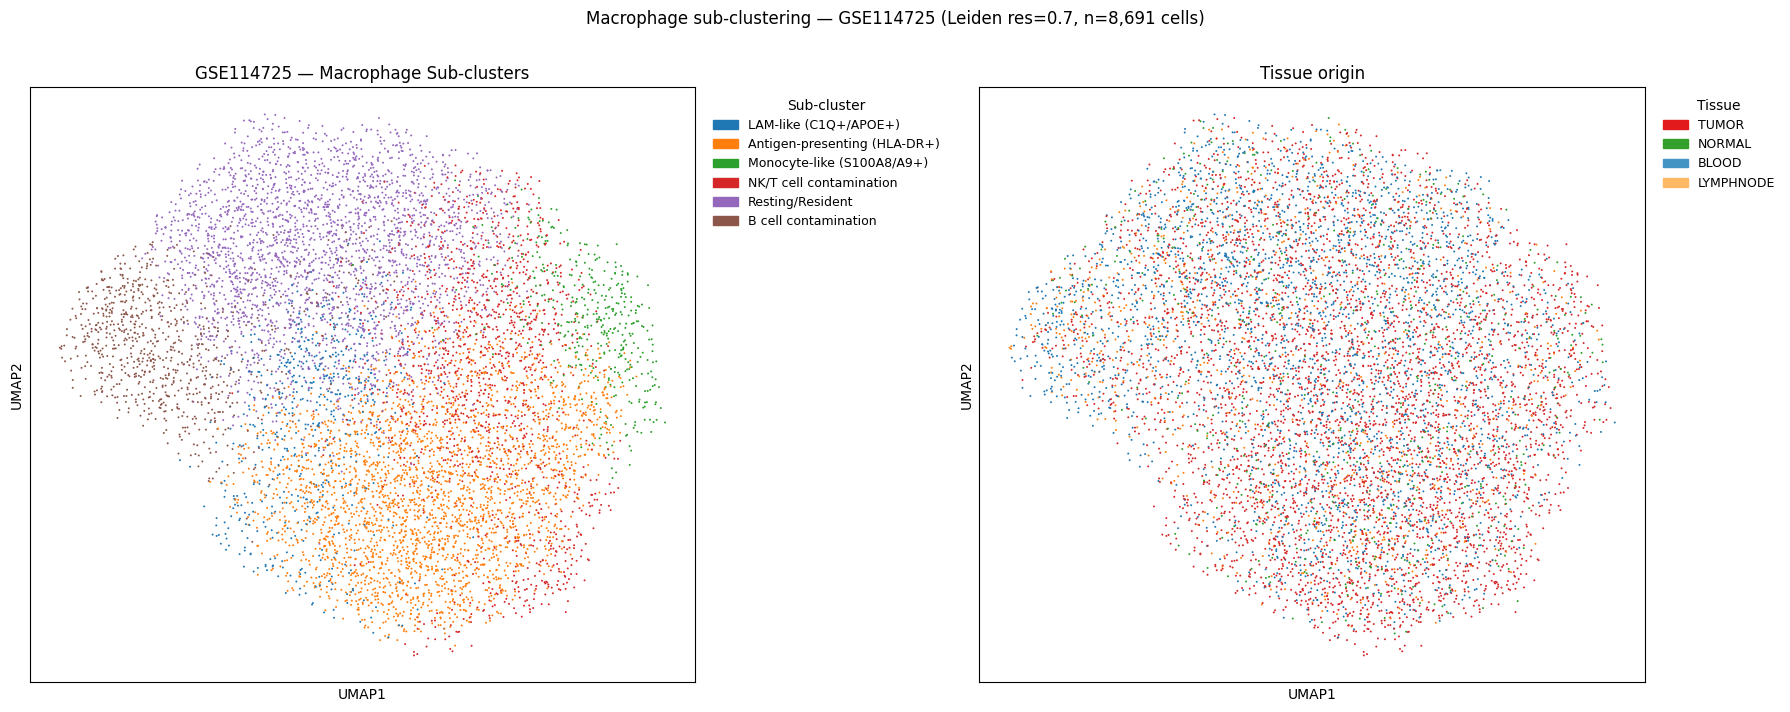

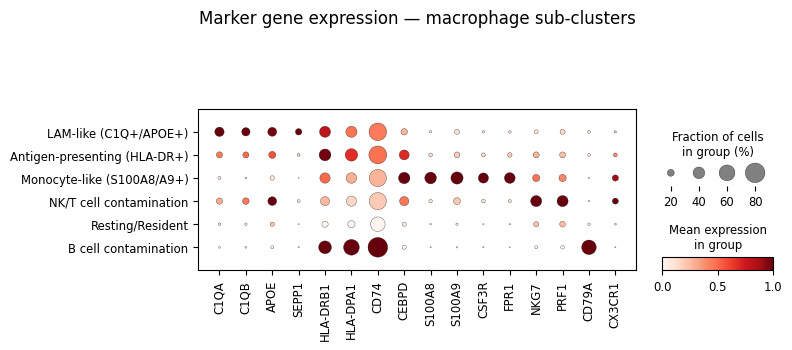

In [10]:
# ── Fix cluster 4 label dynamically ──────────────────────────────────────────
if "n_genes_by_counts" in adata1_mac.obs.columns:
    median_per_cluster = adata1_mac.obs.groupby("mac_leiden_0.7")["n_genes_by_counts"].median()
    overall_median = median_per_cluster.median()
    cluster4_label = "Low quality / unassigned" if median_per_cluster.get("4", overall_median) < 0.7 * overall_median else "Resting/Resident"
    print(f"Cluster 4 → '{cluster4_label}' (median n_genes: {median_per_cluster.get('4', 'N/A'):.0f}, overall: {overall_median:.0f})")
else:
    cluster4_label = "Resting/Resident"

# ── Updated labels ────────────────────────────────────────────────────────────
mac_labels = {
    "0": "LAM-like (C1Q+/APOE+)",
    "1": "Antigen-presenting (HLA-DR+)",
    "2": "Monocyte-like (S100A8/A9+)",
    "3": "NK/T cell contamination",
    "4": cluster4_label,
    "5": "B cell contamination",
}
adata1_mac.obs["mac_subtype"] = adata1_mac.obs["mac_leiden_0.7"].map(mac_labels)
print(adata1_mac.obs["mac_subtype"].value_counts())

# ── UMAP — subtypes + tissue side by side ────────────────────────────────────
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("white")

sc.pl.umap(adata1_mac, color="mac_subtype", title="GSE114725 — Macrophage Sub-clusters",
           legend_loc="none", frameon=True, ax=axes[0], show=False, size=8)

# Safe colour extraction after scanpy assigns them
cats = adata1_mac.obs["mac_subtype"].cat.categories.tolist()
colours = adata1_mac.uns.get("mac_subtype_colors", plt.cm.tab10.colors[:len(cats)])
legend_patches = [mpatches.Patch(color=colours[i], label=label)
                  for i, label in enumerate(cats)]
axes[0].legend(handles=legend_patches, bbox_to_anchor=(1.01, 1), loc="upper left",
               frameon=False, fontsize=9, title="Sub-cluster", title_fontsize=10)

tissue_colours = {"BLOOD": "#4393C3", "LYMPHNODE": "#FDB863", "NORMAL": "#33A02C", "TUMOR": "#E31A1C"}
sc.pl.umap(adata1_mac, color="tissue", title="Tissue origin",
           legend_loc="none", frameon=True, ax=axes[1], show=False, size=8)

tissue_patches = [mpatches.Patch(color=tissue_colours[t], label=t)
                  for t in ["TUMOR", "NORMAL", "BLOOD", "LYMPHNODE"]]
axes[1].legend(handles=tissue_patches, bbox_to_anchor=(1.01, 1), loc="upper left",
               frameon=False, fontsize=9, title="Tissue", title_fontsize=10)

plt.suptitle("Macrophage sub-clustering — GSE114725 (Leiden res=0.7, n=8,691 cells)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_macrophage_subclusters_umap.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# ── Dotplot ───────────────────────────────────────────────────────────────────
all_markers = [g for g in ["C1QA", "C1QB", "APOE", "SEPP1", "TREM2",
                            "HLA-DRB1", "HLA-DPA1", "CD74", "CEBPD",
                            "S100A8", "S100A9", "CSF3R", "FPR1",
                            "NKG7", "PRF1", "CD79A",
                            "RPS12", "RPL13", "CX3CR1"]
               if g in adata1_mac.var_names]

sc.pl.dotplot(adata1_mac, var_names=all_markers, groupby="mac_subtype",
              standard_scale="var", cmap="Reds", dot_max=0.8,
              title="Marker gene expression — macrophage sub-clusters",
              show=False, save=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_macrophage_dotplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [11]:
# Save macrophage sub-clustered object
adata1_mac.write(
    PROCESSED_DIR / "GSE114725_macrophages_subclustered.h5ad",
    compression="gzip"
)
print("Saved")

Saved
